<a href="https://colab.research.google.com/github/banan1999/assignment-01-/blob/main/Assignment%2001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

تم تحميل الفيديو بنجاح!\n
=== معلومات الفيديو الأساسية ===
الأبعاد (Resolution): 360x640
معدل الإطارات (FPS): 23.96
عدد الإطارات الإجمالي (Total Frames): 1425
مدة الفيديو (Duration): 59.46 ثانية
 تم حفظ الصور الأصلية الـ 3 أولاً في مجلد 'extracted_frames 01'.\n


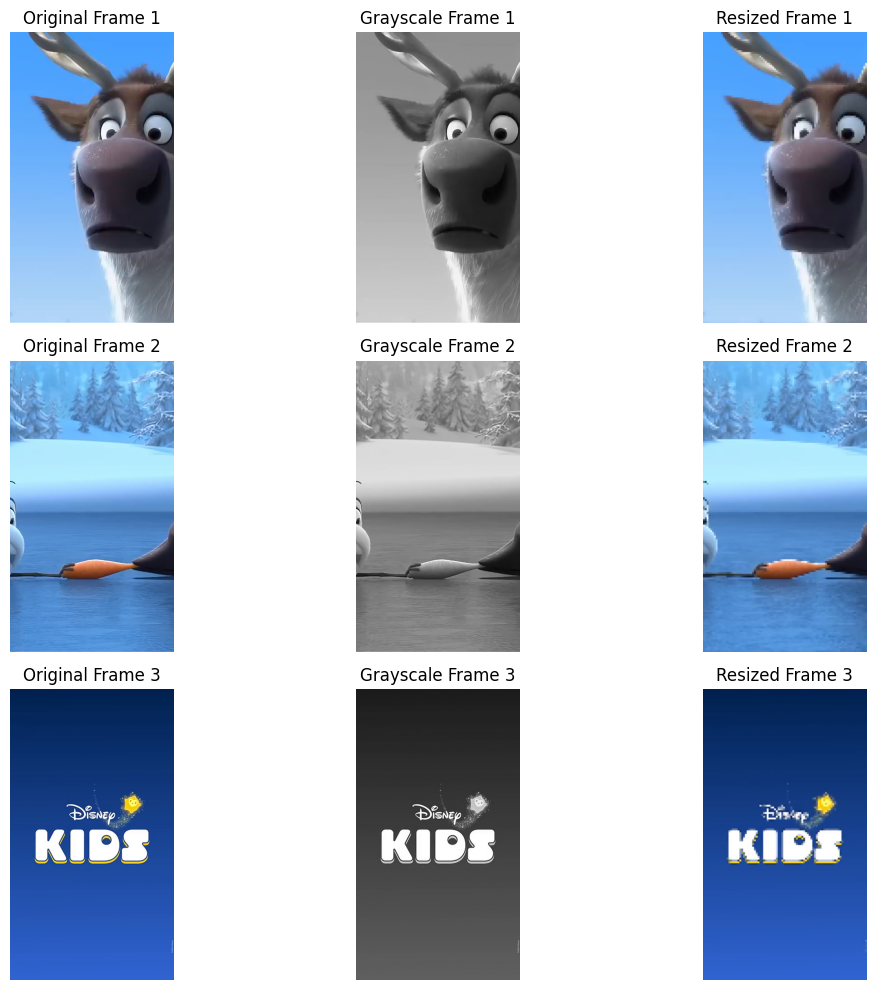

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Task 1: تحميل ملف الفيديو
video_path = '/content/frozen.mp4'
output_folder = 'extracted_frames 01'

#Task 4: إنشاء مجلد لحفظ الإطارات المستخرجة كملفات صور
os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
  print("خطأ: تعذر فتح ملف الفيديو! تأكد من كتابة اسم الملف والامتداد بشكل صحيح.")
else:
  print("تم تحميل الفيديو بنجاح!\\n")
  # Task 2: استخراج وعرض البيانات الأساسية للفيديو
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

  fps = cap.get(cv2.CAP_PROP_FPS)

  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

  duration = total_frames / fps if fps > 0 else 0

  print("=== معلومات الفيديو الأساسية ===")
  print(f"الأبعاد (Resolution): {width}x{height}")
  print(f"معدل الإطارات (FPS): {fps:.2f}")
  print(f"عدد الإطارات الإجمالي (Total Frames): {total_frames}")
  print(f"مدة الفيديو (Duration): {duration:.2f} ثانية")

  # قراءة وتجميع الإطارات بفواصل منتظمة في الذاكرة
  interval = int(fps * 0.5) if fps > 0 else 15
  all_extracted_frames = []
  frame_idx = 0

  while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
      break

    if frame_idx % interval == 0:
      all_extracted_frames.append(frame)
    frame_idx += 1

  cap.release()

  # Task 3: تحديد 3 إطارات رئيسية
  selected_indices = [0, len(all_extracted_frames) // 2, len(all_extracted_frames) - 1]
  selected_originals = [all_extracted_frames[i] for i in selected_indices]

  # Task 4: حفظ الصور المستخرجة
  for i, original_frame in enumerate(selected_originals):
    original_filename = os.path.join(output_folder, f"frame_{i+1}_original.jpg")
    cv2.imwrite(original_filename, original_frame)
  print(f" تم حفظ الصور الأصلية الـ 3 أولاً في مجلد '{output_folder}'.\\n")

  # Task 5: معالجة الصور
  processed_results = []

  for original_frame in selected_originals:
    original_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(original_frame, cv2.COLOR_BGR2GRAY)
    resized_rgb = cv2.resize(original_rgb, (width // 4, height // 4))

    # الاحتفاظ بالتعديلات في الذاكرة لرسمها بيانيًا فقط
    processed_results.append((original_rgb, gray, resized_rgb))

  #Task 6: التصور البياني وعرض النتائج في شبكة 3x3
  fig, axes = plt.subplots(3, 3, figsize=(12, 10))

  for i, (orig, gray, res) in enumerate(processed_results):
    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"Original Frame {i+1}")

    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title(f"Grayscale Frame {i+1}")

    axes[i, 2].imshow(res)
    axes[i, 2].set_title(f"Resized Frame {i+1}")

  # إخفاء محاور الإحداثيات
  for ax in axes.ravel():
    ax.axis('off')

  plt.tight_layout()
  plt.savefig('processed_results_visualization.png', dpi=300)
  plt.show()